# Recall-Bite Frontier & Go/No-Go Pilot for Closure-Certified Temporal Composition

This notebook is a **runnable, minimal-change demo** of the T0 viability pilot from the
*"No Derivation, No Relation"* line of work. The full experiment asks a sharp question:

> Can an LLM emit **sound-but-sub-universal** disjunctive temporal-relation sets at usable
> per-edge **recall**, so that a symbolic **closure** step (qualitative-constraint-network
> path-consistency) can *deduce* tight relations on edges the text never states directly?

The pipeline has two halves:

1. **A self-contained symbolic closure engine** (`engine.py`) — the POINT and Allen-13
   qualitative algebras, built programmatically by the endpoint method, with the
   `close_triangle` path-narrowing operator. This is the *novel mechanism* and it runs in
   pure Python (no API key, milliseconds).
2. **LLM elicitation** of temporal-relation sets across a 5-setting breadth knob
   (`S1_single` → `S5_maximal`) via OpenRouter, then per-edge **recall / breadth** metrics
   that map the *recall-bite frontier* and apply a pre-registered GO/NO-GO gate.

The original run made **4191 billed LLM calls ($0.58)**. To keep this demo free, fast, and
reproducible, **we reuse the already-elicited LLM predictions** that the run stored in its
output (the `predict_<knob>` fields), and recompute the engine + frontier metrics on top of
them. The code below is the original engine and metric code, split into cells — no
re-querying of any model.

**Headline result** (full run): no *real-text* arm clears the recall gate at any knob, so
real-text **read soundness** — not the closure step — is the binding constraint. On clean
synthetic text recall reaches 0.96 and closure resolves deduction edges, i.e. *the closure
mechanism works when the reads are sound* → verdict **NO-GO/NICHE** for real text in iter-1.

In [1]:
# --- Install dependencies (works on Colab and locally) ---
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy + matplotlib are pre-installed on Colab; install them locally at Colab's versions
# so a fresh local kernel matches the Colab environment. On Colab this block is skipped.
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- Imports (original module imports, consolidated for the notebook) ---
import json, os, math, itertools, re
from collections import defaultdict, deque

import numpy as np
import matplotlib.pyplot as plt

# numpy 2.0 compat shims (harmless if already present)
if not hasattr(np, "product"): np.product = np.prod
if not hasattr(np, "alltrue"): np.alltrue = np.all

In [3]:
# --- Data loading: GitHub raw URL with local fallback (Colab-compatible) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-40a89b-no-derivation-no-relation-a-closure-cert/main/round-1/experiment-3/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("dataset   :", data["dataset"])
print("algebra   :", data["algebra"])
print("provenance:", data["provenance"])
print("knobs     :", data["knobs"])
print("n examples:", len(data["examples"]))
print("\nexample[0] gold + predictions:")
ex0 = data["examples"][0]
print("  gold(output):", ex0["output"], "| sentdiff:", ex0["metadata_sentdiff"],
      "| deduction_required:", ex0["metadata_deduction_required"])
for k in data["knobs"]:
    print(f"  predict_{k:12s}: {ex0['predict_'+k]}")
print("\n  marked text:", ex0["input"][:200], "...")

dataset   : TBDense_dense
algebra   : ALLEN
provenance: TimeBank-Dense (.tml TLINKs) -- NarrativeTime stand-in for pilot
knobs     : ['S1_single', 'S2_confident', 'S3_plausible', 'S4_sound', 'S5_maximal']
n examples: 100

example[0] gold + predictions:
  gold(output): VAGUE | sentdiff: 1 | deduction_required: False
  predict_S1_single   : includes
  predict_S2_confident: includes
  predict_S3_plausible: includes|simultaneous
  predict_S4_sound    : UNDERDETERMINED
  predict_S5_maximal  : UNDERDETERMINED

  marked text: ISTANBUL, Turkey (AP)_ Some 1,500 ethnic Albanians marched Sunday in downtown Istanbul, burning Serbian flags to protest the killings of ethnic Albanians by Serb police in southern Serb Kosovo provinc ...


## Configuration

All tunable knobs in one place. They are set to small demo values; the comments give the
original full-run values. Because the heavy LLM elicitation is already cached in the data
file, every cell below is pure CPU and runs in well under a second even at the maximum
setting.

In [5]:
# ---- Tunable demo parameters ----
KNOB_ORDER = ["S1_single", "S2_confident", "S3_plausible", "S4_sound", "S5_maximal"]
KNOBS      = data.get("knobs", KNOB_ORDER)   # breadth knobs to evaluate (all 5 are cached)

MAX_EDGES    = 100      # per-edge examples to score. demo data has 100. (full run: 240/arm)
BOOTSTRAP_B  = 1000     # doc-clustered bootstrap resamples for the recall 95% CI (full: 1000)

# pre-registered gates / seed (verbatim from the original method.py config)
RECALL_GATE_ALLEN = 0.85     # coarse-Allen arm (sound-but-incomplete) recall bar
RECALL_GATE_POINT = 0.90     # convex point-algebra arm (PC complete) recall bar
SEED = 20260617

EXAMPLES = data["examples"][:MAX_EDGES]
ALGEBRA  = data["algebra"]
print(f"Scoring {len(EXAMPLES)} edges of arm '{data['dataset']}' ({ALGEBRA}) across {len(KNOBS)} knobs.")

Scoring 100 edges of arm 'TBDense_dense' (ALLEN) across 5 knobs.


## 1. The closure engine (`engine.py`)

Two qualitative calculi, both built **programmatically** (no external table files):

* **POINT** — convex point algebra over event start-points `{<, =, >}`. Path-consistency is
  *complete* here (an exact inconsistency certificate). The only non-convex relation `{<,>}`
  is widened to the universal set to keep PC complete (and each widening is counted).
* **ALLEN** — the 13-relation Allen interval algebra. Its composition table is generated by
  the **endpoint method** (enumerate weak orderings of the six interval endpoints) and
  cross-checked against the dossier's verified GQR cells. Allen PC is sound but *incomplete*.

`close_triangle` is the per-triangle length-2 narrowing used for the frontier metrics:
`path = compose(AB, BC)`, then `inter = path ∩ AC`. If `inter` becomes a singleton, closure
has *deduced* a tight relation; if it becomes empty, closure has detected an inconsistency.

The code below is copied verbatim from `engine.py`.

In [6]:
# ================= engine.py (verbatim): Allen-13 + Point algebras =================
ALLEN_BASE = ["B", "BI", "D", "DI", "O", "OI", "M", "MI", "S", "SI", "F", "FI", "E"]
ALLEN_CONVERSE = {"B": "BI", "BI": "B", "D": "DI", "DI": "D", "O": "OI", "OI": "O",
                  "M": "MI", "MI": "M", "S": "SI", "SI": "S", "F": "FI", "FI": "F", "E": "E"}


def _allen_rel(xs, xe, ys, ye):
    """Atomic Allen relation of interval X=(xs,xe) to Y=(ys,ye) from endpoint ranks."""
    if not (xs < xe and ys < ye):
        return None
    if xs == ys and xe == ye:
        return "E"
    if xe < ys:
        return "B"
    if ye < xs:
        return "BI"
    if xe == ys:
        return "M"
    if ye == xs:
        return "MI"
    if xs == ys:
        return "S" if xe < ye else "SI"
    if xe == ye:
        return "F" if xs > ys else "FI"
    if xs < ys and ye < xe:
        return "DI"
    if ys < xs and xe < ye:
        return "D"
    if xs < ys < xe < ye:
        return "O"
    if ys < xs < ye < xe:
        return "OI"
    return None


def _build_allen_compose():
    """Generate the Allen base x base composition table via endpoint enumeration."""
    comp = {(a, b): set() for a in ALLEN_BASE for b in ALLEN_BASE}
    for asg in itertools.product(range(6), repeat=6):
        As, Ae, Bs, Be, Cs, Ce = asg
        if not (As < Ae and Bs < Be and Cs < Ce):
            continue
        rab = _allen_rel(As, Ae, Bs, Be)
        rbc = _allen_rel(Bs, Be, Cs, Ce)
        rac = _allen_rel(As, Ae, Cs, Ce)
        if rab is None or rbc is None or rac is None:
            continue
        comp[(rab, rbc)].add(rac)
    return {k: frozenset(v) for k, v in comp.items()}


POINT_BASE = ["<", "=", ">"]
POINT_CONVERSE = {"<": ">", "=": "=", ">": "<"}
POINT_COMPOSE = {
    ("=", "="): frozenset({"="}),
    ("<", "="): frozenset({"<"}), ("=", "<"): frozenset({"<"}),
    (">", "="): frozenset({">"}), ("=", ">"): frozenset({">"}),
    ("<", "<"): frozenset({"<"}),
    (">", ">"): frozenset({">"}),
    ("<", ">"): frozenset({"<", "=", ">"}),
    (">", "<"): frozenset({"<", "=", ">"}),
}
POINT_NONCONVEX = frozenset({"<", ">"})  # the only non-convex point relation (`!=`)


class Algebra:
    """A qualitative calculus with relation sets stored as frozensets of base symbols."""

    def __init__(self, name, base, converse, compose_bb, identity, convex_widen=None):
        self.name = name
        self.base = list(base)
        self.universe = frozenset(base)
        self.empty = frozenset()
        self.identity = frozenset(identity)
        self._conv = dict(converse)
        self._comp = dict(compose_bb)
        self._nonconvex = convex_widen

    def converse(self, s):
        return frozenset(self._conv[r] for r in s)

    def compose(self, a, b):
        if not a or not b:
            return self.empty
        out = set()
        for x in a:
            for y in b:
                out |= self._comp[(x, y)]
        return frozenset(out)

    def is_nonconvex(self, s):
        return self._nonconvex is not None and s == self._nonconvex

    def widen(self, s):
        """Return (possibly-widened set, fired?)."""
        if self._nonconvex is not None and s == self._nonconvex:
            return self.universe, True
        return s, False

    def label(self, s):
        if not s:
            return "EMPTY"
        if s == self.universe:
            return "UNIVERSE"
        return "|".join(r for r in self.base if r in s)


def build_point_algebra():
    return Algebra("POINT", POINT_BASE, POINT_CONVERSE, POINT_COMPOSE,
                   frozenset({"="}), convex_widen=POINT_NONCONVEX)


def build_allen_algebra():
    return Algebra("ALLEN", ALLEN_BASE, ALLEN_CONVERSE, _build_allen_compose(),
                   frozenset({"E"}), convex_widen=None)


def close_triangle(alg, ab, bc, ac):
    """Length-2 path A-B-C narrowing the query edge A-C.

    path  = compose(ab, bc)   (with convex widening applied + counted)
    inter = path & ac         (widening applied + counted)
    """
    n_widen = 0
    path = alg.compose(ab, bc)
    path, w = alg.widen(path)
    n_widen += int(w)
    inter = path & ac
    inter, w = alg.widen(inter)
    n_widen += int(w)
    return {
        "path": path,
        "inter": inter,
        "empty": len(inter) == 0,
        "singleton": len(inter) == 1,
        "n_widen": n_widen,
    }


# build once and keep a registry, exactly as method.py does
ALG = {"POINT": build_point_algebra(), "ALLEN": build_allen_algebra()}
print("POINT base:", ALG["POINT"].base)
print("ALLEN base:", ALG["ALLEN"].base, "| n compose cells:", len(ALG["ALLEN"]._comp))

POINT base: ['<', '=', '>']
ALLEN base: ['B', 'BI', 'D', 'DI', 'O', 'OI', 'M', 'MI', 'S', 'SI', 'F', 'FI', 'E'] | n compose cells: 169


### Engine spot-checks and a worked closure deduction

First the composition spot-checks from `engine.py`'s self-test, then three worked
`close_triangle` examples that show the three things closure can do to a query edge:
**deduce a singleton**, **leave it unresolved**, or **detect an inconsistency (collapse)**.

In [7]:
pt, al = ALG["POINT"], ALG["ALLEN"]

# --- composition spot-checks (engine.py __main__) ---
print("ALLEN  B o B  =", sorted(al.compose(frozenset({'B'}),  frozenset({'B'}))))   # before o before -> before
print("ALLEN  D o DI =", sorted(al.compose(frozenset({'D'}),  frozenset({'DI'}))))  # during o contains -> broad
print("POINT  < o >  =", sorted(pt.compose(frozenset({'<'}),  frozenset({'>'}))))    # -> universal (no info)

U = al.universe
print("\n--- worked close_triangle examples (Allen) ---")

# (1) DEDUCTION: A before B, B before C, query A?C unknown (universe) -> closure deduces 'before'
r1 = close_triangle(al, frozenset({'B'}), frozenset({'B'}), U)
print(f"(1) AB={{B}} BC={{B}} AC=universe -> inter={al.label(r1['inter'])} "
      f"singleton={r1['singleton']}  (closure DEDUCED a tight relation)")

# (2) UNRESOLVED: A contains B, B contains C, but AB and BC composed stay broad
r2 = close_triangle(al, frozenset({'DI'}), frozenset({'B'}), U)
print(f"(2) AB={{DI}} BC={{B}} AC=universe -> inter={al.label(r2['inter'])} "
      f"singleton={r2['singleton']}  (closure narrowed but did NOT pin a singleton)")

# (3) COLLAPSE: path says 'before' but the stated query edge says 'after' -> empty = inconsistency
r3 = close_triangle(al, frozenset({'B'}), frozenset({'B'}), frozenset({'BI'}))
print(f"(3) AB={{B}} BC={{B}} AC={{BI}} -> inter={al.label(r3['inter'])} "
      f"empty={r3['empty']}  (closure CERTIFIED an inconsistency)")

ALLEN  B o B  = ['B']
ALLEN  D o DI = ['B', 'BI', 'D', 'DI', 'E', 'F', 'FI', 'M', 'MI', 'O', 'OI', 'S', 'SI']
POINT  < o >  = ['<', '=', '>']

--- worked close_triangle examples (Allen) ---
(1) AB={B} BC={B} AC=universe -> inter=B singleton=True  (closure DEDUCED a tight relation)
(2) AB={DI} BC={B} AC=universe -> inter=B|DI|O|M|FI singleton=False  (closure narrowed but did NOT pin a singleton)
(3) AB={B} BC={B} AC={BI} -> inter=EMPTY empty=True  (closure CERTIFIED an inconsistency)


## 2. Coarse vocabulary ↔ algebra mappings (`corpora.py`)

Every emitted/gold relation lives in a shared coarse vocabulary
`{before, after, includes, is_included, simultaneous}` (+ `VAGUE`/underdetermined) and is
mapped into the arm's algebra. Recall is measured at the coarse-label level; closure uses the
mapped algebra sets. The helpers below are copied verbatim from `corpora.py`; the only added
function is `label_to_algset`, which turns a stored `predict_<knob>` string (e.g.
`"includes|simultaneous"` or `"UNDERDETERMINED"`) back into an algebra set.

In [8]:
# ============= corpora.py (verbatim): coarse vocabulary <-> algebra maps =============
COARSE_VOCAB_ALLEN = ["before", "after", "includes", "is_included", "simultaneous"]
COARSE_VOCAB_POINT = ["before", "after", "simultaneous"]

COARSE_TO_POINT = {
    "before": frozenset({"<"}), "after": frozenset({">"}),
    "simultaneous": frozenset({"="}),
    "includes": frozenset({"<", "="}), "is_included": frozenset({"=", ">"}),
}
COARSE_TO_ALLEN = {
    "before": frozenset({"B"}), "after": frozenset({"BI"}),
    "includes": frozenset({"DI"}), "is_included": frozenset({"D"}),
    "simultaneous": frozenset({"E"}),
}
COARSE_TO_POINT_ATOM = {"before": "<", "after": ">", "simultaneous": "="}


def coarse_to_set(coarse, algebra):
    """Map one coarse label to the arm's algebra relation set."""
    if coarse in ("VAGUE", "underdetermined", "UNDERDETERMINED"):
        return universe_set(algebra)
    if algebra == "POINT":
        return COARSE_TO_POINT[coarse]
    return COARSE_TO_ALLEN[coarse]


def universe_set(algebra):
    return ALG[algebra].universe


def emitted_set(coarse_labels, underdetermined, algebra):
    """Union of coarse labels -> algebra set. underdetermined/empty -> universe."""
    if underdetermined or not coarse_labels:
        return universe_set(algebra)
    out = set()
    for c in coarse_labels:
        out |= set(coarse_to_set(c, algebra))
    return frozenset(out) if out else universe_set(algebra)


def gold_atom(coarse, algebra):
    """Atomic gold base symbol used for the recall indicator (None for VAGUE)."""
    if coarse == "VAGUE":
        return None
    if algebra == "POINT":
        return COARSE_TO_POINT_ATOM[coarse]
    return next(iter(COARSE_TO_ALLEN[coarse]))


def label_to_algset(label, algebra):
    """Turn a stored predict_<knob> label back into an emitted algebra set.

    Labels are produced by the original build_examples(): a "|"-joined list of coarse
    labels, or the sentinels "UNDERDETERMINED"/"EMPTY" (both -> the universal set).
    """
    if not label or label in ("UNDERDETERMINED", "EMPTY"):
        return emitted_set([], True, algebra)
    return emitted_set(label.split("|"), False, algebra)


# sanity: round-trip a couple of the cached predictions
for lab in ["before", "includes|simultaneous", "UNDERDETERMINED"]:
    s = label_to_algset(lab, ALGEBRA)
    print(f"{lab:24s} -> {ALG[ALGEBRA].label(s):20s} (breadth {len(s)})")

before                   -> B                    (breadth 1)
includes|simultaneous    -> DI|E                 (breadth 2)
UNDERDETERMINED          -> UNIVERSE             (breadth 13)


## 3. Per-edge frontier metrics (`method.py`)

For a fixed breadth knob, each edge yields a binary **soundness** indicator
(`gold ∈ emitted set`) and a **breadth** (`|emitted set|`). Pooled recall gets a
**document-clustered bootstrap 95% CI** (resampling documents, to respect the within-document
error correlation ρ), and ρ itself is the one-way ICC of the soundness indicator grouped by
document. The error-type mix splits sound reads into *exact* (singleton), *tight*, and *loose*,
versus *overcommit-unsound*. `icc_oneway` and `clustered_bootstrap_ci` are verbatim from
`method.py`; `knob_metrics` is `arm_knob_metrics` with its data source pointed at the cached
per-edge examples.

In [9]:
# ================= method.py (verbatim): rho (ICC) + clustered bootstrap =================
def icc_oneway(groups):
    """One-way random-effects ICC(1) of a binary indicator grouped by document."""
    groups = [g for g in groups if len(g) >= 2]
    if len(groups) < 2:
        return None
    N = sum(len(g) for g in groups)
    k = len(groups)
    grand = sum(sum(g) for g in groups) / N
    ms_between = sum(len(g) * (np.mean(g) - grand) ** 2 for g in groups) / (k - 1)
    ss_within = sum(sum((x - np.mean(g)) ** 2 for x in g) for g in groups)
    ms_within = ss_within / (N - k) if N > k else 0.0
    sum_n2 = sum(len(g) ** 2 for g in groups)
    n0 = (N - sum_n2 / N) / (k - 1)
    denom = ms_between + (n0 - 1) * ms_within
    if denom == 0:
        return 0.0
    return float((ms_between - ms_within) / denom)


def clustered_bootstrap_ci(doc_to_vals, B=BOOTSTRAP_B, seed=SEED, alpha=0.05):
    """95% CI for the pooled mean of a 0/1 indicator, resampling DOCUMENTS with replacement."""
    docs = [d for d, v in doc_to_vals.items() if v]
    if len(docs) < 2:
        allv = [x for v in doc_to_vals.values() for x in v]
        m = float(np.mean(allv)) if allv else float("nan")
        return [m, m]
    rng = np.random.default_rng(seed)
    arrs = {d: np.array(doc_to_vals[d], dtype=float) for d in docs}
    means = []
    nd = len(docs)
    for _ in range(B):
        pick = rng.integers(0, nd, nd)
        vals = np.concatenate([arrs[docs[i]] for i in pick])
        means.append(vals.mean())
    lo, hi = np.quantile(means, [alpha / 2, 1 - alpha / 2])
    return [float(lo), float(hi)]


# ============ method.py arm_knob_metrics, reading the CACHED per-edge examples ============
def knob_metrics(examples, knob):
    """Per-edge recall/breadth/error-type metrics for one breadth knob."""
    recalls, breadths, univ, cats = [], [], [], defaultdict(int)
    sound_by_doc = defaultdict(list)
    n_eval = 0
    for ex in examples:
        algebra = ex["metadata_algebra"]
        alg = ALG[algebra]
        label = ex.get(f"predict_{knob}")
        if label is None:
            continue
        aset = label_to_algset(label, algebra)
        usize = len(alg.universe)
        gatom = gold_atom(ex["output"], algebra)
        breadths.append(len(aset))
        univ.append(1 if aset == alg.universe else 0)
        if gatom is None:  # VAGUE gold -> excluded from recall/error-type
            continue
        n_eval += 1
        sound = 1 if gatom in aset else 0
        recalls.append(sound)
        sound_by_doc[ex["metadata_docid"]].append(sound)
        if not sound:
            cats["overcommit_unsound"] += 1
        elif len(aset) == 1:
            cats["exact_correct"] += 1
        elif aset == alg.universe or len(aset) > max(2, usize // 2):
            cats["sound_loose"] += 1
        else:
            cats["sound_tight"] += 1
    n = max(1, n_eval)
    recall = float(np.mean(recalls)) if recalls else float("nan")
    recall_ci = clustered_bootstrap_ci(sound_by_doc) if recalls else [float("nan"), float("nan")]
    return {
        "knob": knob,
        "recall": recall,
        "recall_ci95": recall_ci,
        "n_eval_edges": n_eval,
        "breadth_mean": float(np.mean(breadths)) if breadths else float("nan"),
        "breadth_median": float(np.median(breadths)) if breadths else float("nan"),
        "universal_rate": float(np.mean(univ)) if univ else float("nan"),
        "unsound_rate": (1 - recall) if recalls else float("nan"),
        "exact_correct_rate": cats["exact_correct"] / n,
        "sound_tight_rate": cats["sound_tight"] / n,
        "sound_loose_rate": cats["sound_loose"] / n,
        "overcommit_unsound_rate": cats["overcommit_unsound"] / n,
        "rho_within_doc": icc_oneway(list(sound_by_doc.values())),
    }

## 4. Map the recall-bite frontier across the breadth knob

Run `knob_metrics` for every knob `S1_single → S5_maximal`. As the prompt asks for broader
("more sound") relation sets, **breadth grows and recall climbs** toward the gate — the core
tension the pilot was built to measure. We also flag whether each knob clears the
pre-registered Allen recall gate (0.85).

In [10]:
frontier = [knob_metrics(EXAMPLES, k) for k in KNOBS]

gate = RECALL_GATE_POINT if ALGEBRA == "POINT" else RECALL_GATE_ALLEN
hdr = f"{'knob':13s} {'recall':>7s} {'95% CI':>15s} {'breadth':>8s} {'univ%':>6s} {'rho':>6s} {'>=gate':>7s}"
print(hdr); print("-" * len(hdr))
for r in frontier:
    ci = r["recall_ci95"]
    rho = r["rho_within_doc"]
    rho_s = f"{rho:.3f}" if rho is not None else "  n/a"
    cleared = "YES" if (r["recall"] == r["recall"] and r["recall"] >= gate) else "no"
    print(f"{r['knob']:13s} {r['recall']:7.3f} [{ci[0]:.2f},{ci[1]:.2f}]   "
          f"{r['breadth_mean']:8.2f} {100*r['universal_rate']:5.1f}% {rho_s:>6s} {cleared:>7s}")

mono = all(frontier[i]["breadth_mean"] <= frontier[i+1]["breadth_mean"] + 1e-9
           for i in range(len(frontier)-1))
best = max(frontier, key=lambda r: r["recall"])
print(f"\nbreadth monotone-increasing in knob: {mono}")
print(f"best recall = {best['recall']:.3f} at {best['knob']} "
      f"(gate {gate}: {'CLEARED' if best['recall'] >= gate else 'NOT cleared -> NO-GO/NICHE for this arm'})")

knob           recall          95% CI  breadth  univ%    rho  >=gate
--------------------------------------------------------------------
S1_single       0.439 [0.34,0.54]       1.00   0.0%  0.028      no
S2_confident    0.463 [0.36,0.57]       1.00   0.0%  0.026      no
S3_plausible    0.488 [0.39,0.59]       1.22   1.0% -0.002      no
S4_sound        0.659 [0.55,0.76]       3.64  20.0%  0.051      no
S5_maximal      0.707 [0.59,0.81]       4.73  30.0%  0.118      no

breadth monotone-increasing in knob: True
best recall = 0.707 at S5_maximal (gate 0.85: NOT cleared -> NO-GO/NICHE for this arm)


## 5. Visualization

Left: the **soundness-recall tradeoff** — mean breadth vs per-edge recall across the knob,
with the recall gate marked. Right: the **error-type mix** per knob — how the broadening
prompt converts *overcommit-unsound* reads into *sound* (exact/tight/loose) ones. This is the
demo-scale analogue of the original `breadth_vs_recall.jpg` figure.

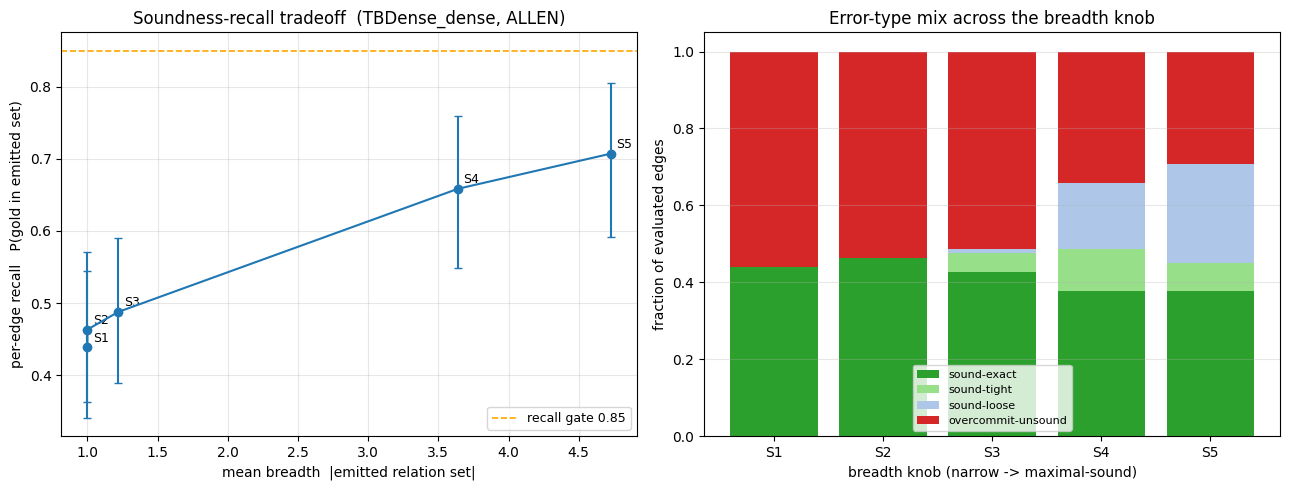


Takeaway: broadening the prompt trades precision for recall (breadth up, recall up),
but on this real-text arm recall stays below the 0.85 Allen gate -> read soundness,
not the closure engine, is the binding constraint (verdict NO-GO/NICHE for real text).


In [11]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

# ---- Left: breadth vs recall across knobs ----
xs = [r["breadth_mean"] for r in frontier]
ys = [r["recall"] for r in frontier]
los = [r["recall"] - r["recall_ci95"][0] for r in frontier]
his = [r["recall_ci95"][1] - r["recall"] for r in frontier]
axL.errorbar(xs, ys, yerr=[los, his], fmt="o-", color="#1f77b4", capsize=3, zorder=3)
for r in frontier:
    axL.annotate(r["knob"].split("_")[0], (r["breadth_mean"], r["recall"]),
                 fontsize=9, xytext=(4, 4), textcoords="offset points")
axL.axhline(gate, ls="--", c="orange", lw=1.2, label=f"recall gate {gate}")
axL.set_xlabel("mean breadth  |emitted relation set|")
axL.set_ylabel("per-edge recall   P(gold in emitted set)")
axL.set_title(f"Soundness-recall tradeoff  ({data['dataset']}, {ALGEBRA})")
axL.legend(fontsize=9); axL.grid(alpha=0.3)

# ---- Right: stacked error-type mix per knob ----
labels = [r["knob"].split("_")[0] for r in frontier]
exact  = [r["exact_correct_rate"] for r in frontier]
tight  = [r["sound_tight_rate"] for r in frontier]
loose  = [r["sound_loose_rate"] for r in frontier]
unsnd  = [r["overcommit_unsound_rate"] for r in frontier]
x = np.arange(len(frontier))
b = np.zeros(len(frontier))
for vals, name, col in [(exact, "sound-exact", "#2ca02c"),
                        (tight, "sound-tight", "#98df8a"),
                        (loose, "sound-loose", "#aec7e8"),
                        (unsnd, "overcommit-unsound", "#d62728")]:
    axR.bar(x, vals, bottom=b, label=name, color=col)
    b = b + np.array(vals)
axR.set_xticks(x); axR.set_xticklabels(labels)
axR.set_xlabel("breadth knob (narrow -> maximal-sound)")
axR.set_ylabel("fraction of evaluated edges")
axR.set_title("Error-type mix across the breadth knob")
axR.legend(fontsize=8, loc="lower center"); axR.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("\nTakeaway: broadening the prompt trades precision for recall (breadth up, recall up),")
print("but on this real-text arm recall stays below the 0.85 Allen gate -> read soundness,")
print("not the closure engine, is the binding constraint (verdict NO-GO/NICHE for real text).")